In [1]:
# Part 1
# 1.1
%pip install opencv-python
%pip install matplotlib
%pip install numpy pandas

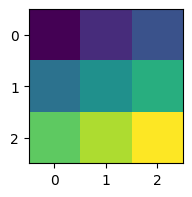

In [31]:

# 1.2
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

test = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

plt.figure(figsize=(2, 2))
plt.imshow(test)
plt.show()


In [2]:
# Part 2
# Task 1:
class GroceryManager:

    def __init__(self):
        self.items = {}

    def add_item(self, item, quantity, price):
        self.items[item] = {
            "quantity": quantity,
            "price": price
        }

    def remove_item(self, item):
        if item in self.items:
            del self.items[item]
        else:
            print("Item not found.")

    def view_list(self):
        if not self.items:
            print("Grocery list is empty.")
            return

        for item, details in self.items.items():
            print(item, "-", details["quantity"], "x", details["price"])

    def calculate_total(self):
        total = 0

        for details in self.items.values():
            total += details["quantity"] * details["price"]

        return total



manager = GroceryManager()

manager.add_item("Milk", 2, 280)
manager.add_item("Bread", 1, 150)
manager.add_item("Eggs", 12, 25)

manager.view_list()

print("Total cost:", manager.calculate_total())

manager.remove_item("Bread")
manager.view_list()


Milk - 2 x 280
Bread - 1 x 150
Eggs - 12 x 25
Total cost: 1010
Milk - 2 x 280
Eggs - 12 x 25


In [3]:
# Task 2
students = {
    "1": {
        "Name": "Raghib",
        "Major": "Artificial Intelligence",
        "Grades": [0, 2, 9, 5]
    },
    "2": {
        "Name": "Umar",
        "Major": "Computer Science",
        "Grades": [72, 68, 80, 75]
    },
    "3": {
        "Name": "Fahad",
        "Major": "Artificial Intelligence",
        "Grades": [95, 91, 98, 89]
    }
}


def top_student(records):
    highest_average = 0
    top_name = ""

    for student in records.values():
        average = sum(student["Grades"]) / len(student["Grades"])

        if average > highest_average:
            highest_average = average
            top_name = student["Name"]

    return top_name


def search_by_major(records, major):
    for student in records.values():
        if student["Major"] == major:
            print(student["Name"])


print("Student with highest average:", top_student(students))

print("\nStudents in Artificial Intelligence:")
search_by_major(students, "Artificial Intelligence")

Student with highest average: Fahad

Students in Artificial Intelligence:
Raghib
Fahad


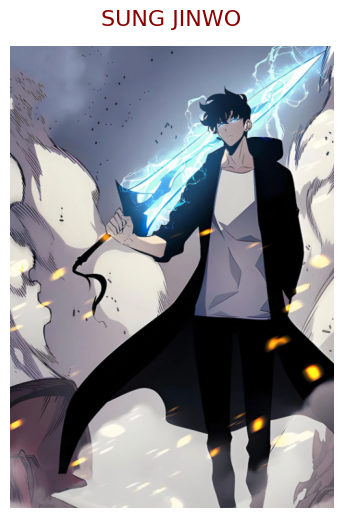

In [12]:
# Part 3
# Task 3
import cv2
import matplotlib.pyplot as plt

image_path = '/content/Sung Jinwo.png'


image = cv2.imread(image_path)

if image is None:
    print("Error: Image not found.")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title('SUNG JINWO', fontsize=16, color='darkred', pad=15)
    plt.show()

### Task 4: Interactive Geometry & Blank Canvas

An 800x800 black canvas, a five-ring target board in alternating colors, a bounding box
around the outermost ring, and the exact center coordinates printed.

Canvas size          : 800 x 800
Exact center (x, y)  : (400, 400)
Outer circle radius  : 350
Bounding box         : top-left (50, 50), bottom-right (750, 750)


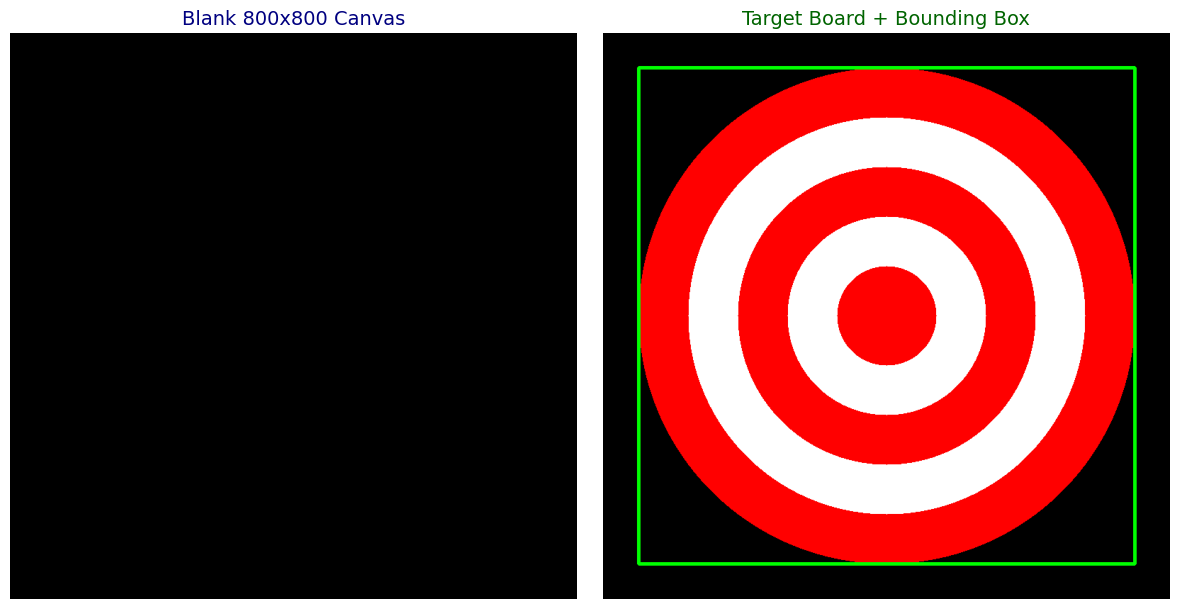

In [13]:
# Task 4
CANVAS_SIZE = 800
canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.uint8)

center_x = CANVAS_SIZE // 2
center_y = CANVAS_SIZE // 2
center = (center_x, center_y)

# Five concentric circles, drawn largest first so smaller ones sit on top.

radii  = [350, 280, 210, 140, 70]
colors = [(0, 0, 255), (255, 255, 255), (0, 0, 255), (255, 255, 255), (0, 0, 255)]

for radius, color in zip(radii, colors):
    cv2.circle(canvas, center, radius, color, thickness=-1)

# Bounding box around the outermost circle.
outer_radius = radii[0]
top_left     = (center_x - outer_radius, center_y - outer_radius)
bottom_right = (center_x + outer_radius, center_y + outer_radius)
cv2.rectangle(canvas, top_left, bottom_right, (0, 255, 0), thickness=4)

print(f"Canvas size          : {CANVAS_SIZE} x {CANVAS_SIZE}")
print(f"Exact center (x, y)  : {center}")
print(f"Outer circle radius  : {outer_radius}")
print(f"Bounding box         : top-left {top_left}, bottom-right {bottom_right}")

canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.uint8))
axes[0].set_title('Blank 800x800 Canvas', fontsize=14, color='navy')
axes[0].axis('off')

axes[1].imshow(canvas_rgb)
axes[1].set_title('Target Board + Bounding Box', fontsize=14, color='darkgreen')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Full image      : 498 x 712
ROI slice rows  : 206:506
ROI slice cols  : 99:399
ROI shape       : (300, 300, 3)


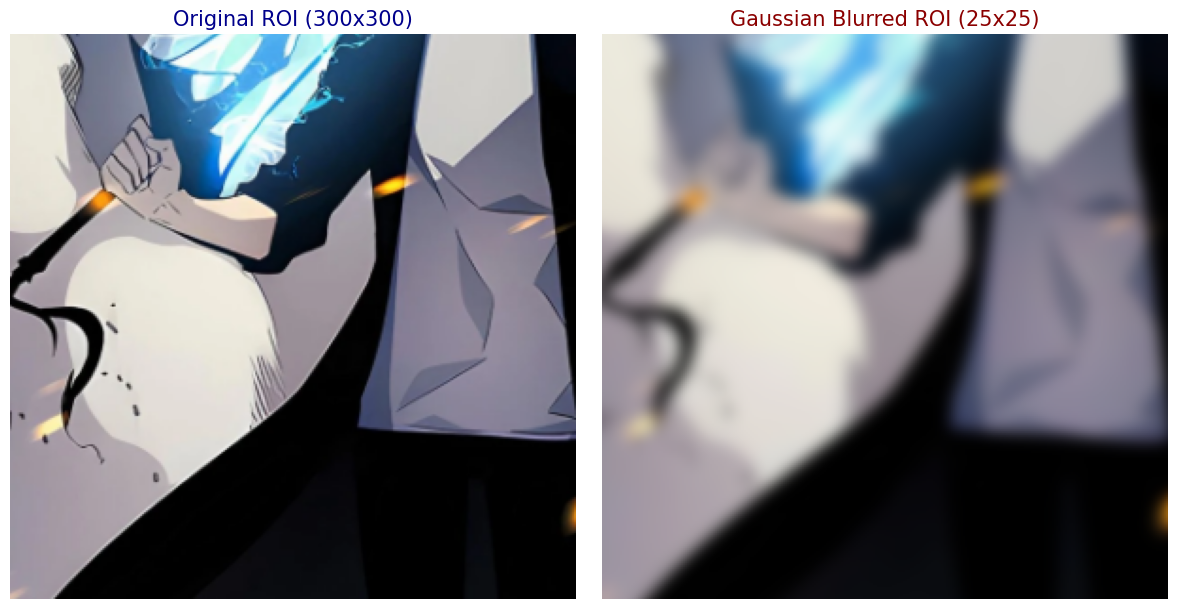

In [17]:
# Task 5
HIGH_RES_PATH = '/content/Sung Jinwo.png'
hi_res = cv2.imread(HIGH_RES_PATH)
hi_res_rgb = cv2.cvtColor(hi_res, cv2.COLOR_BGR2RGB)


blurred_rgb = cv2.GaussianBlur(hi_res_rgb, (25, 25), 0)

ROI_SIZE = 300
h, w = hi_res_rgb.shape[:2]

if h < ROI_SIZE or w < ROI_SIZE:
    raise ValueError(f"Image is {w}x{h}; needs to be at least {ROI_SIZE}x{ROI_SIZE} for the ROI.")

# Exact-center slice bounds.
start_y = (h - ROI_SIZE) // 2
start_x = (w - ROI_SIZE) // 2
end_y   = start_y + ROI_SIZE
end_x   = start_x + ROI_SIZE

roi_original = hi_res_rgb[start_y:end_y, start_x:end_x]
roi_blurred  = blurred_rgb[start_y:end_y, start_x:end_x]

print(f"Full image      : {w} x {h}")
print(f"ROI slice rows  : {start_y}:{end_y}")
print(f"ROI slice cols  : {start_x}:{end_x}")
print(f"ROI shape       : {roi_original.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(roi_original)
axes[0].set_title('Original ROI (300x300)', fontsize=15, color='darkblue')
axes[0].axis('off')

axes[1].imshow(roi_blurred)
axes[1].set_title('Gaussian Blurred ROI (25x25)', fontsize=15, color='darkred')
axes[1].axis('off')

plt.tight_layout()
plt.show()

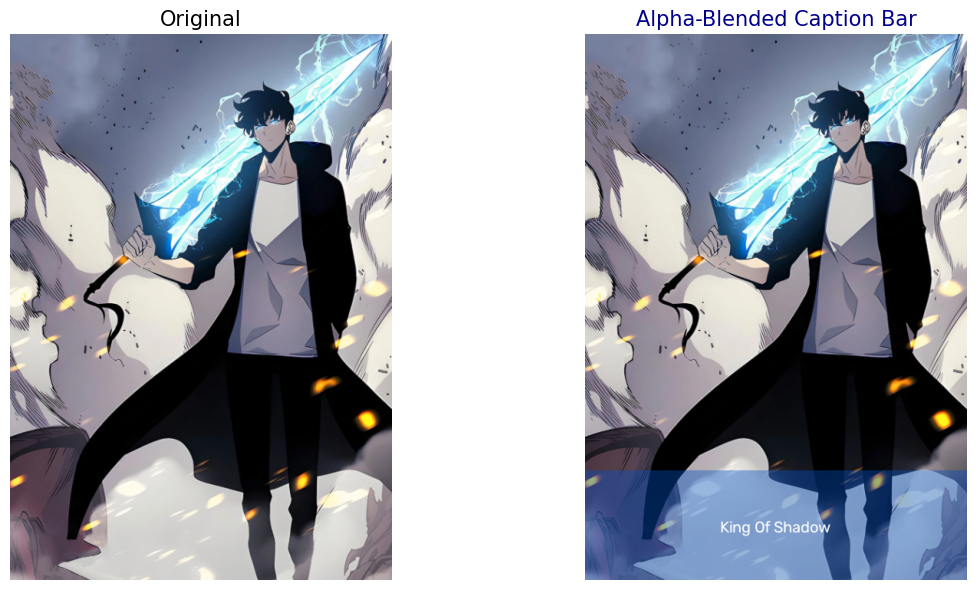

In [20]:
# Task 6
CAPTION_PATH  = '/content/Sung Jinwo.png'
caption_img = cv2.imread(CAPTION_PATH)
caption_img = caption_img.copy()
h, w = caption_img.shape[:2]


overlay = caption_img.copy()
bar_top = int(h * 0.80)
cv2.rectangle(overlay, (0, bar_top), (w, h), (200, 80, 0), thickness=-1)

# Semi-transparent blend: alpha on the original, beta on the overlay.
alpha = 0.6
beta  = 1 - alpha
blended = cv2.addWeighted(caption_img, alpha, overlay, beta, 0)

# Caption text over the transparent box.
text = "King Of Shadow"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = max(w / 700.0, 0.6)
thickness = max(int(font_scale * 2), 1)

(text_w, text_h), baseline = cv2.getTextSize(text, font, font_scale, thickness)
text_x = (w - text_w) // 2
text_y = bar_top + (h - bar_top + text_h) // 2

cv2.putText(blended, text, (text_x, text_y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].imshow(cv2.cvtColor(caption_img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original', fontsize=15, color='black')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
axes[1].set_title('Alpha-Blended Caption Bar', fontsize=15, color='darkblue')
axes[1].axis('off')

plt.tight_layout()
plt.show()

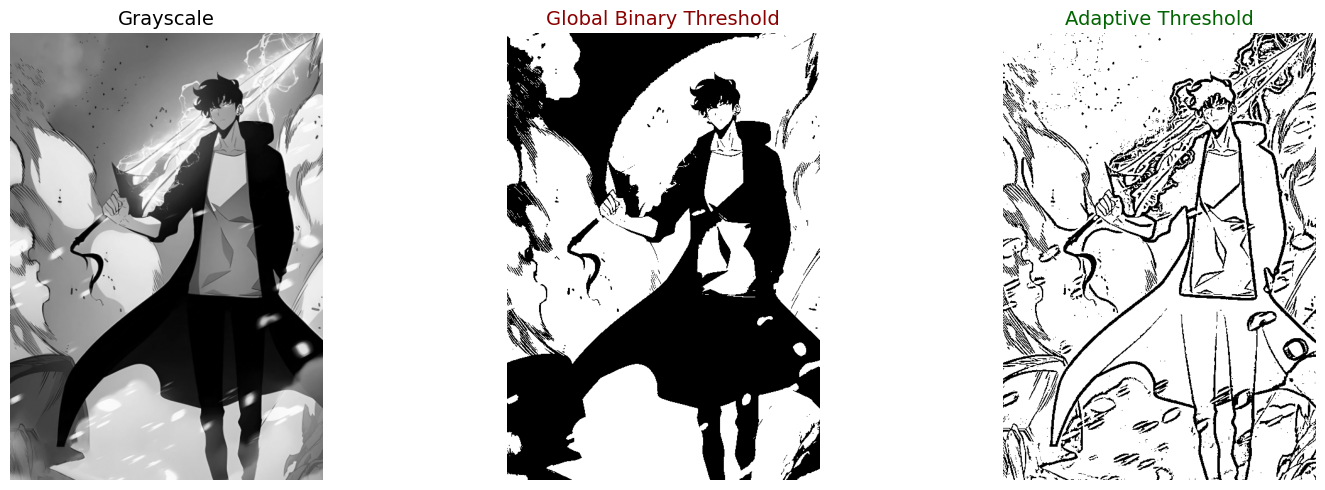

In [22]:
# Task 7
DOC_PATH      = '/content/Sung Jinwo.png'
doc = cv2.imread(DOC_PATH)
gray = cv2.cvtColor(doc, cv2.COLOR_BGR2GRAY)

# 1) Global binary threshold - single cutoff at 127.
_, global_thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 2) Adaptive threshold - cutoff computed per 11x11 neighbourhood, minus a constant of 2.
adaptive_thresh = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=11,
    C=2
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale', fontsize=14, color='black')
axes[0].axis('off')

axes[1].imshow(global_thresh, cmap='gray')
axes[1].set_title('Global Binary Threshold', fontsize=14, color='darkred')
axes[1].axis('off')

axes[2].imshow(adaptive_thresh, cmap='gray')
axes[2].set_title('Adaptive Threshold', fontsize=14, color='darkgreen')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Rotation matrix (2x3):
[[  0.5657   0.5657 -93.2397]
 [ -0.5657   0.5657 295.4717]]


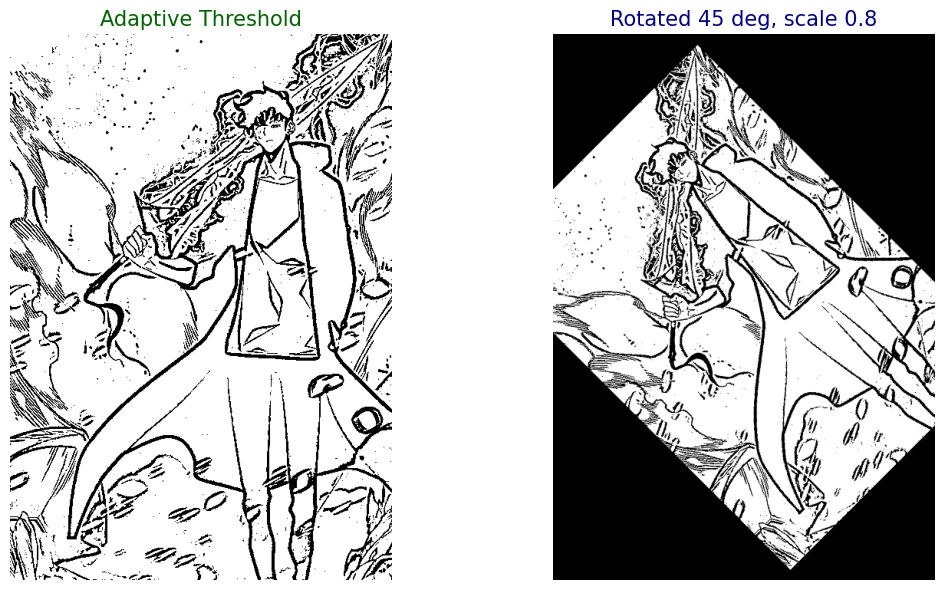

In [23]:
# Rotate the adaptive threshold output by exactly 45 degrees, scaled by 0.8.
rows, cols = adaptive_thresh.shape
rotation_center = (cols / 2.0, rows / 2.0)

rotation_matrix = cv2.getRotationMatrix2D(rotation_center, angle=45, scale=0.8)
print("Rotation matrix (2x3):")
print(np.round(rotation_matrix, 4))

rotated = cv2.warpAffine(
    adaptive_thresh,
    rotation_matrix,
    (cols, rows),
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=0
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(adaptive_thresh, cmap='gray')
axes[0].set_title('Adaptive Threshold', fontsize=15, color='darkgreen')
axes[0].axis('off')

axes[1].imshow(rotated, cmap='gray')
axes[1].set_title('Rotated 45 deg, scale 0.8', fontsize=15, color='darkblue')
axes[1].axis('off')

plt.tight_layout()
plt.show()

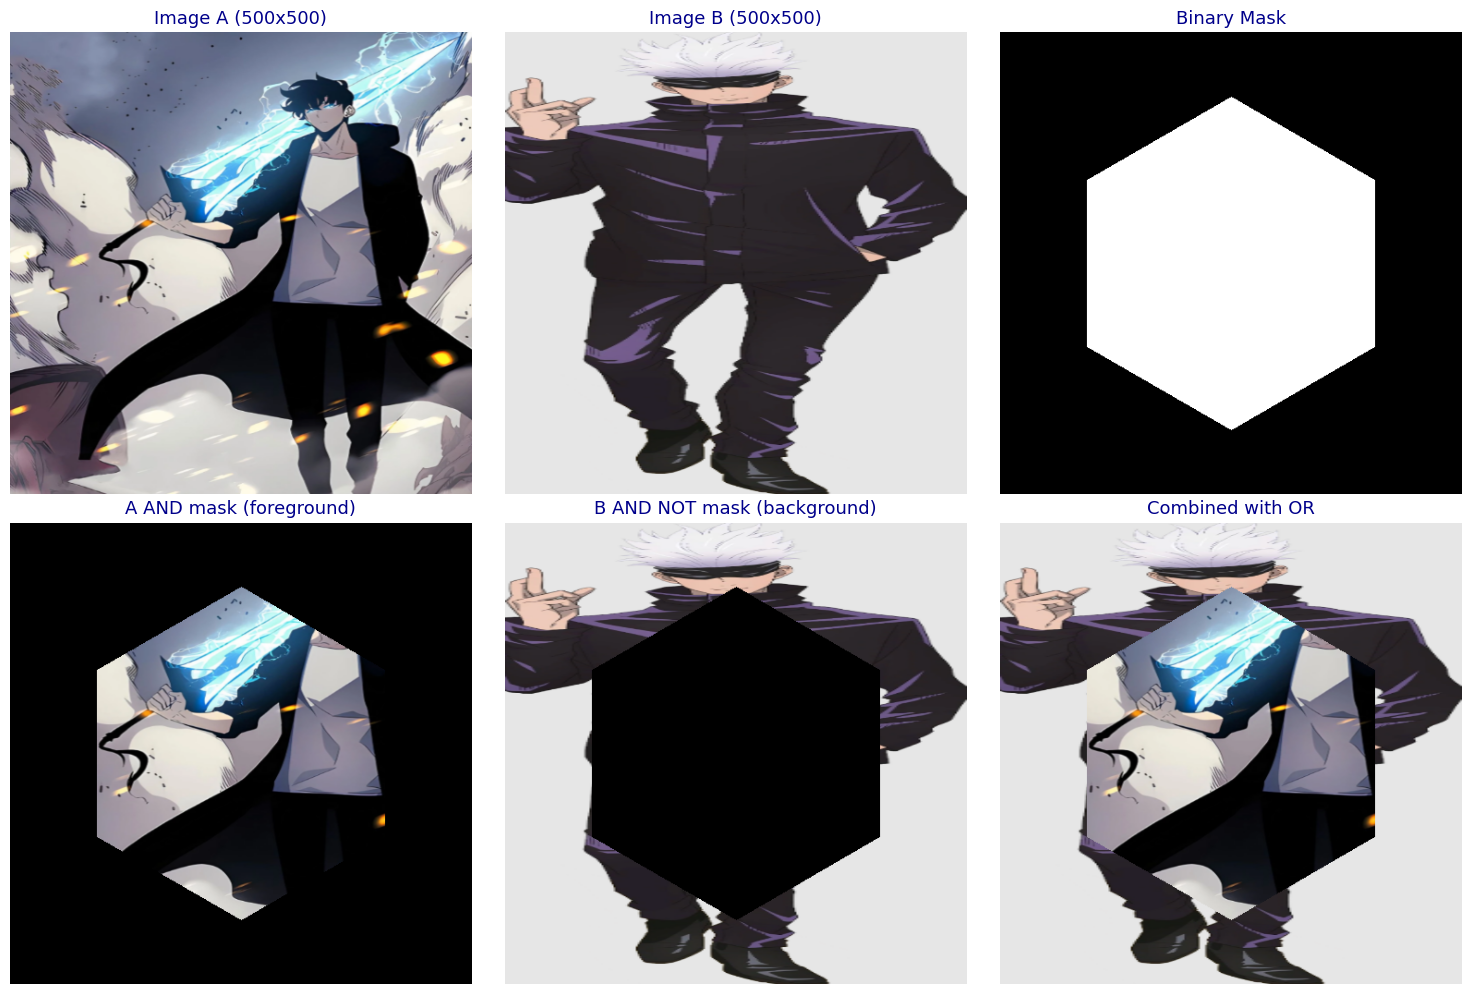

In [27]:
# Task 8
IMAGE_A       = '/content/Sung Jinwo.png'
IMAGE_B       = '/content/Gojo Saturo.png'
SIZE = 500

img_a = cv2.resize(cv2.imread(IMAGE_A) , (SIZE, SIZE))
img_b = cv2.resize(cv2.imread(IMAGE_B) , (SIZE, SIZE))

# Binary mask: black canvas with a thick white polygon (hexagon) in the center.
mask = np.zeros((SIZE, SIZE), dtype=np.uint8)
cx, cy, radius = SIZE // 2, SIZE // 2, 180
angles = np.linspace(0, 2 * np.pi, 6, endpoint=False) - np.pi / 2
polygon = np.array([[int(cx + radius * np.cos(a)), int(cy + radius * np.sin(a))] for a in angles],
                   dtype=np.int32)
cv2.fillPoly(mask, [polygon], 255)

mask_inv = cv2.bitwise_not(mask)

# Foreground from image A (inside the polygon), background from image B (outside it).
foreground = cv2.bitwise_and(img_a, img_a, mask=mask)
background = cv2.bitwise_and(img_b, img_b, mask=mask_inv)
combined   = cv2.bitwise_or(foreground, background)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

panels = [
    (cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB), 'Image A (500x500)', None),
    (cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB), 'Image B (500x500)', None),
    (mask, 'Binary Mask', 'gray'),
    (cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB), 'A AND mask (foreground)', None),
    (cv2.cvtColor(background, cv2.COLOR_BGR2RGB), 'B AND NOT mask (background)', None),
    (cv2.cvtColor(combined, cv2.COLOR_BGR2RGB), 'Combined with OR', None),
]

for ax, (data, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(data, cmap=cmap)
    ax.set_title(title, fontsize=13, color='darkblue')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [30]:
# Task 9
profile_img = cv2.imread(IMAGE_A)
profile_rgb = cv2.cvtColor(profile_img, cv2.COLOR_BGR2RGB)

# Split the channels and flatten each 2D array into 1D.
red_channel   = profile_rgb[:, :, 0].flatten()
green_channel = profile_rgb[:, :, 1].flatten()
blue_channel  = profile_rgb[:, :, 2].flatten()

print(f"Image shape        : {profile_rgb.shape}")
print(f"Pixels per channel : {red_channel.shape[0]}")

df = pd.DataFrame({
    'Red':   red_channel,
    'Green': green_channel,
    'Blue':  blue_channel
})

print("\nFirst five pixels:")
print(df.head())

print("\nStatistical Summary")
print(df.describe())

print("\n Requested statistics")
for channel in ['Red', 'Green', 'Blue']:
    col = df[channel]
    print(f"{channel:<6} mean={col.mean():7.2f}  min={col.min():4d}  "
          f"max={col.max():4d}  std={col.std():7.2f}")

Image shape        : (712, 498, 3)
Pixels per channel : 354576

First five pixels:
   Red  Green  Blue
0  121    127   155
1  119    127   156
2  119    127   157
3  119    127   157
4  118    127   157

Statistical Summary
                 Red          Green           Blue
count  354576.000000  354576.000000  354576.000000
mean      124.128308     126.145461     133.661658
std        80.692687      80.545030      78.282789
min         0.000000       0.000000       0.000000
25%        55.000000      60.000000      73.000000
50%       129.000000     130.000000     151.000000
75%       201.000000     205.000000     204.000000
max       255.000000     255.000000     255.000000

 Requested statistics
Red    mean= 124.13  min=   0  max= 255  std=  80.69
Green  mean= 126.15  min=   0  max= 255  std=  80.55
Blue   mean= 133.66  min=   0  max= 255  std=  78.28
